# Pipeline

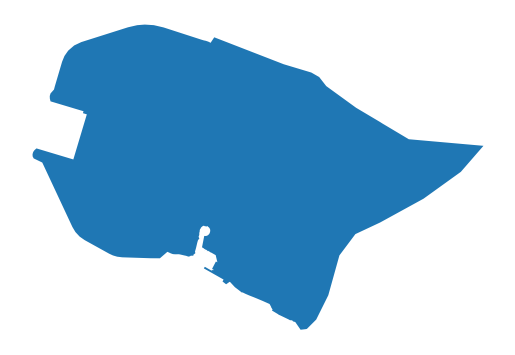

In [34]:
import osmnx as ox

boundaries_gdf = ox.geocode_to_gdf('Санкт-Петербург, Василеостровский район')
boundaries_gdf.plot().set_axis_off()

In [35]:
boundaries_geom = boundaries_gdf.union_all()

In [36]:
local_crs = boundaries_gdf.estimate_utm_crs()

## Blocks

In [37]:
BC_TAGS = {
    'roads': {
      "highway": ["construction","crossing","living_street","motorway","motorway_link","motorway_junction","pedestrian","primary","primary_link","raceway","residential","road","secondary","secondary_link","services","tertiary","tertiary_link","track","trunk","trunk_link","turning_circle","turning_loop","unclassified",],
      "service": ["living_street", "emergency_access"]
    },
    'railways': {
      "railway": "rail"
    },
    'water': {
      'riverbank':True,
      'reservoir':True,
      'basin':True,
      'dock':True,
      'canal':True,
      'pond':True,
      'natural':['water','bay'],
      'waterway':['river','canal','ditch'],
      'landuse':'basin',
      'water': 'lake'
    }
}

In [38]:
water_gdf = ox.features_from_polygon(boundaries_geom, BC_TAGS['water'])
railways_gdf = ox.features_from_polygon(boundaries_geom, BC_TAGS['railways'])
roads_gdf = ox.features_from_polygon(boundaries_geom, BC_TAGS['roads'])

ConnectionError: ('Connection aborted.', TimeoutError('The write operation timed out'))

In [ ]:
for gdf in [water_gdf, roads_gdf, railways_gdf, boundaries_gdf]:
    gdf.reset_index(inplace=True, drop=True)
    gdf.to_crs(local_crs, inplace=True)

In [ ]:
from blocksnet.blocks.cutting import preprocess_urban_objects, cut_urban_blocks
from blocksnet.blocks.postprocessing import postprocess_urban_blocks

lines_gdf, polygons_gdf = preprocess_urban_objects(roads_gdf, railways_gdf, water_gdf)
blocks_gdf = cut_urban_blocks(boundaries_gdf, lines_gdf, polygons_gdf)
blocks_gdf = postprocess_urban_blocks(blocks_gdf)